Imports

In [ ]:
import notebook
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from platform import python_version
import xgboost as xgb
import graphviz
import sklearn
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_absolute_percentage_error as MAPE


print(f"python: v {python_version()}")
print(f"Jupyter Notebook: v {notebook.__version__}")
print(f"numpy: v {np.__version__}")
print(f"pandas: v {pd.__version__}")
print(f"seaborn: v {sns.__version__}")
print(f"graphviz: v {graphviz.__version__}")
print(f"matplotlib: v {matplotlib.__version__}")
print(f"sklearn: v {sklearn.__version__}")
print(f"XGBoost: v {xgb.__version__}")

python: v 3.10.12
Jupyter Notebook: v 7.4.7
numpy: v 1.25.2
pandas: v 2.3.3
seaborn: v 0.13.2
graphviz: v 0.21
matplotlib: v 3.7.2
sklearn: v 1.7.2
XGBoost: v 3.1.1


Import Data

In [ ]:
matthijs_appliances = ['TV', 'waterboiler', 'oven', 'washing_machine', 'refrigerator', 'electric_heater', 'dryer']
robin_appliances = ['washing_machine', 'toaster', 'kettle', 'TV', 'production']
manolis_appliances = ['kettle', 'toaster', 'washer_dryer', 'coffee_machine', 'heatpump', 'TV']


df_2h = pd.read_csv("Predictions/ablation_results_pwc_hourly_house_matthijs.csv")
df_2 = pd.read_csv("Predictions/ablation_results_pwc_house_matthijs.csv")

df_6h = pd.read_csv("Predictions/ablation_results_pwc_hourly_house_manolis.csv")
df_6 = pd.read_csv("Predictions/ablation_results_pwc_house_manolis.csv")


df_9h = pd.read_csv("Predictions/ablation_results_pwc_hourly_house_robin.csv")
df_9 = pd.read_csv("Predictions/ablation_results_pwc_house_robin.csv")

print("CSV read successfully.")

CSV read successfully.


Helper Functions

In [ ]:
# This function calculates the marginal contribution of each appliance to the performance metric (e.g., MAE) along with the standard deviation of that contribution across different subsets of included appliances.
# This function parameters are:
# - df_day_metrics: The DataFrame containing the daily performance metrics for each scenario.
# - appliances: The list of appliance columns to consider for calculating marginal contributions.
# - metric: The performance metric to use for calculating marginal contributions (default is "MAE")
def marginal_contribution_with_std(df_day_metrics, appliances=None, metric="MAE"):
    df = df_day_metrics.copy()
    df["IncludedSet"] = df["Included"].fillna("").apply(lambda s: frozenset([x for x in s.split(",") if x]))
    perf = df.groupby("IncludedSet")[metric].mean().to_dict()

    rows = []
    for a in appliances:
        deltas = [perf[S | {a}] - perf[S] for S in perf if (a not in S and (S | {a}) in perf)]
        rows.append({
            "Appliance": a,
            "marginal_mean": float(np.mean(deltas)) if deltas else np.nan,
            "marginal_std": float(np.std(deltas, ddof=1)) if len(deltas) > 1 else np.nan,
            "n": int(len(deltas))
        })
    return pd.DataFrame(rows).sort_values("marginal_mean")

# This function calculates the average increase in MAE when each appliance is dropped from the model, compared to the baseline scenario where all appliances are included.
# This function parameters are:
# - df_day_metrics: The DataFrame containing the daily performance metrics for each scenario.
def summarize_ablation_importance(df_day_metrics):
    base = df_day_metrics[df_day_metrics["Scenario"] == "incl_A1_A2_A3_A4_A5_A6_A7_A8_A9"]["MAE"].mean()

    drop = (
        df_day_metrics[df_day_metrics["Scenario"].str.startswith("drop_")]
        .groupby("Dropped", as_index=False)["MAE"]
        .mean()
    )
    drop["MAE_increase_vs_baseline"] = drop["MAE"] - base
    drop = drop.sort_values("MAE_increase_vs_baseline", ascending=False)
    return base, drop

Main cell for Ablations metrics

In [ ]:
# For house 9
best = (
        df_9
        .groupby(["Scenario","Included","n_included"], as_index=False)["MAE"]
        .mean()
        .sort_values("MAE")
    )
print("Best scenarios for house 9:")
best.to_csv("ablation_results_house_9_bestConf.csv", index=False)
print(best.head(20))
marginal_importance_9 = marginal_contribution_with_std(df_9, appliances=robin_appliances, metric="MAE")
print("\nMarginal importance for house 9:")
print(marginal_importance_9)
baseline_MAE = df_9[df_9["Scenario"] == "incl_washing_machine_toaster_kettle_TV_production"]["MAE"].mean()
print(f"\nBaseline MAE for house 9: {baseline_MAE:.2f}")
print("\n" + "-"*30 + "\n")

# For house 2
best_2 = (
        df_2
        .groupby(["Scenario","Included","n_included"], as_index=False)["MAE"]
        .mean()
        .sort_values("MAE")
    )
print("\nBest scenarios for house 2:")
best_2.to_csv("ablation_results_house_2_bestConf.csv", index=False)
print(best_2.head(20))
marginal_importance_2 = marginal_contribution_with_std(df_2, appliances=matthijs_appliances, metric="MAE")
print("\nMarginal importance for house 2:")
print(marginal_importance_2)
baseline_MAE_2 = df_2[df_2["Scenario"] == "incl_TV_waterboiler_oven_washing_machine_refrigerator_electric_heater_dryer"]["MAE"].mean()
print(f"\nBaseline MAE for house 2: {baseline_MAE_2:.2f}")
print("\n" + "-"*30 + "\n")

# For house 6
best_6 = (
        df_6
        .groupby(["Scenario","Included","n_included"], as_index=False)["MAE"]
        .mean()
        .sort_values("MAE")
    )
print("\nBest scenarios for house 6:")
best_6.to_csv("ablation_results_house_6_bestConf.csv", index=False)
print(best_6.head(20))
marginal_importance_6 = marginal_contribution_with_std(df_6, appliances=manolis_appliances, metric="MAE")
print("\nMarginal importance for house 6:")
print(marginal_importance_6)
baseline_MAE_6 = df_6[df_6["Scenario"] == "incl_kettle_toaster_washer_dryer_coffee_machine_heatpump_TV"]["MAE"].mean()
print(f"\nBaseline MAE for house 6: {baseline_MAE_6:.2f}")

Best scenarios for house 9:
                                             Scenario  \
3                                      incl_kettle_TV   
1                                  incl_TV_production   
17                 incl_washing_machine_TV_production   
12                  incl_toaster_kettle_TV_production   
26                incl_washing_machine_toaster_kettle   
2                                         incl_kettle   
19                     incl_washing_machine_kettle_TV   
29     incl_washing_machine_toaster_kettle_production   
28  incl_washing_machine_toaster_kettle_TV_production   
0                                             incl_TV   
18                        incl_washing_machine_kettle   
27             incl_washing_machine_toaster_kettle_TV   
24                    incl_washing_machine_toaster_TV   
20          incl_washing_machine_kettle_TV_production   
9                          incl_toaster_TV_production   
16                            incl_washing_machine_TV   
25 

Visualization of Ablation Results

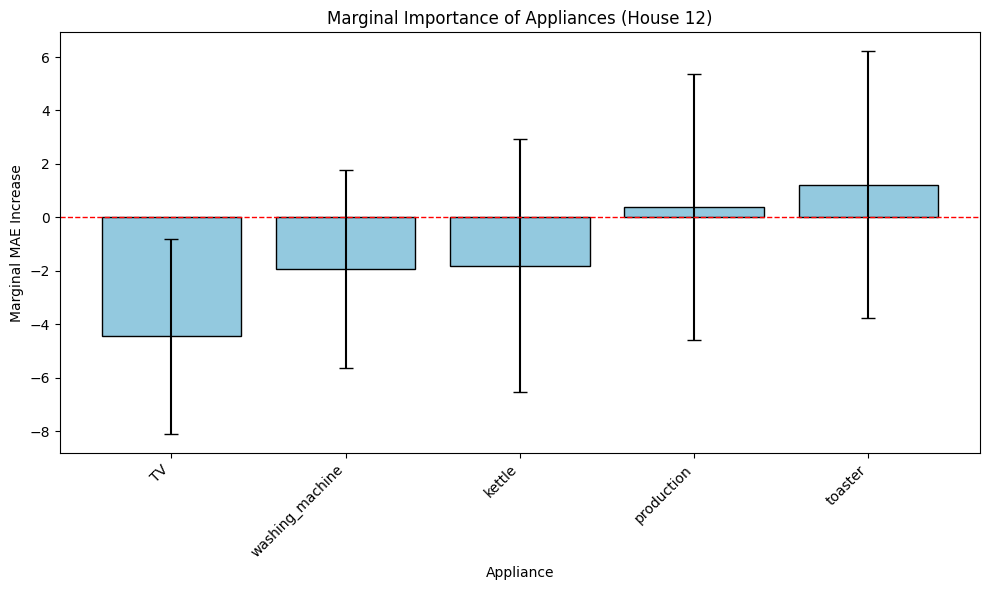

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Appliance", y="marginal_mean", data=marginal_importance_9, color="skyblue", edgecolor="black")
plt.errorbar(x=marginal_importance_9["Appliance"], y=marginal_importance_9["marginal_mean"], yerr=marginal_importance_9["marginal_std"], fmt="none", ecolor="black", capsize=5)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Marginal Importance of Appliances (House 12)")
plt.ylabel("Marginal MAE Increase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x="Appliance", y="marginal_mean", data=marginal_importance_2, color="lightgreen", edgecolor="black")
plt.errorbar(x=marginal_importance_2["Appliance"], y=marginal_importance_2["marginal_mean"], yerr=marginal_importance_2["marginal_std"], fmt="none", ecolor="black", capsize=5)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Marginal Importance of Appliances (House 2)")
plt.ylabel("Marginal MAE Increase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x="Appliance", y="marginal_mean", data=marginal_importance_6, color="salmon", edgecolor="black")
plt.errorbar(x=marginal_importance_6["Appliance"], y=marginal_importance_6["marginal_mean"], yerr=marginal_importance_6["marginal_std"], fmt="none", ecolor="black", capsize=5)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Marginal Importance of Appliances (House 6)")
plt.ylabel("Marginal MAE Increase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()